# SilSim Analysis

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
# --- Bootstrap imports so your local package is picked up and reloaded ---
from pathlib import Path

## RocketPy Output

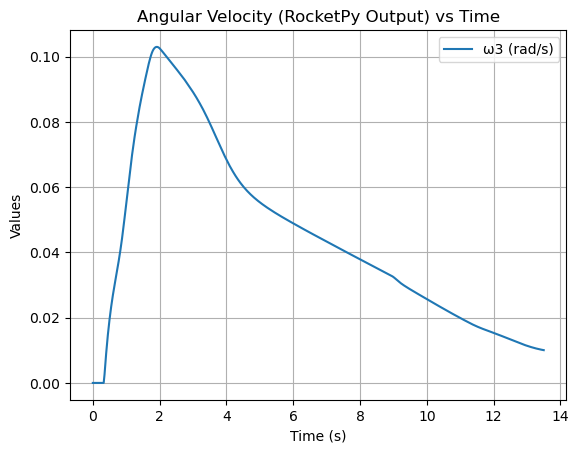

In [18]:
## Optional data exported direclty from RocketPy ##
# data_rocketpy = pd.read_csv(Path("..") / "data" / "rocketpy_output.csv")

# t = data_rocketpy['# Time (s)'].to_numpy()
# mask = t < 13.972 # Time before apogee
# t_rpy = t[mask]
# w1_rpy = data_rocketpy[' ω1 (rad/s)'].to_numpy()[mask]
# w2_rpy = data_rocketpy[' ω2 (rad/s)'].to_numpy()[mask]
# w3_rpy = data_rocketpy[' ω3 (rad/s)'].to_numpy()[mask]
# a1_rpy = data_rocketpy[' α1 (rad/s²)'].to_numpy()[mask]
# a2_rpy = data_rocketpy[' α2 (rad/s²)'].to_numpy()[mask]
# a3_rpy = data_rocketpy[' α3 (rad/s²)'].to_numpy()[mask]
# v1_rpy = data_rocketpy[' Vx (m/s)'].to_numpy()[mask]
# v2_rpy = data_rocketpy[' Vy (m/s)'].to_numpy()[mask]
# v3_rpy = data_rocketpy[' Vz (m/s)'].to_numpy()[mask]
# x_rpy = data_rocketpy[' X (m)'].to_numpy()[mask]
# y_rpy = data_rocketpy[' Y (m)'].to_numpy()[mask]
# z_rpy = data_rocketpy[' Z (m)'].to_numpy()[mask] - data_rocketpy[' Z (m)'].to_numpy()[0]  # Normalize altitude

data_rpy = pd.read_csv(Path("..") / "data" / "silsim_output2.csv")

t_rpy = data_rpy['time'].to_numpy()
x_rpy = data_rpy['state_0'].to_numpy()
y_rpy = data_rpy['state_1'].to_numpy()
z_rpy = data_rpy['state_2'].to_numpy()
v1_rpy = data_rpy['state_3'].to_numpy()
v2_rpy = data_rpy['state_4'].to_numpy()
v3_rpy = data_rpy['state_5'].to_numpy()
e0_rpy = data_rpy['state_6'].to_numpy()
e1_rpy = data_rpy['state_7'].to_numpy()
e2_rpy = data_rpy['state_8'].to_numpy()
e3_rpy = data_rpy['state_9'].to_numpy()
w1_rpy = data_rpy['state_10'].to_numpy()
w2_rpy = data_rpy['state_11'].to_numpy()
w3_rpy = data_rpy['state_12'].to_numpy()

# Plot w3 and a3 on the same graph
plt.figure()
plt.plot(t_rpy, w3_rpy, label='ω3 (rad/s)')
# plt.plot(t_rpy, a3_rpy, label='Angular Acceleration α3 (rad/s²)')
plt.xlabel('Time (s)')
plt.ylabel('Values')
plt.title('Angular Velocity (RocketPy Output) vs Time')
# plt.ylim(-0.1, 0.1)
# plt.axhline(y=925, color='r', linestyle='--', label='Motor Burnout')
plt.legend()
plt.grid()
plt.show()

## State Estimation Output

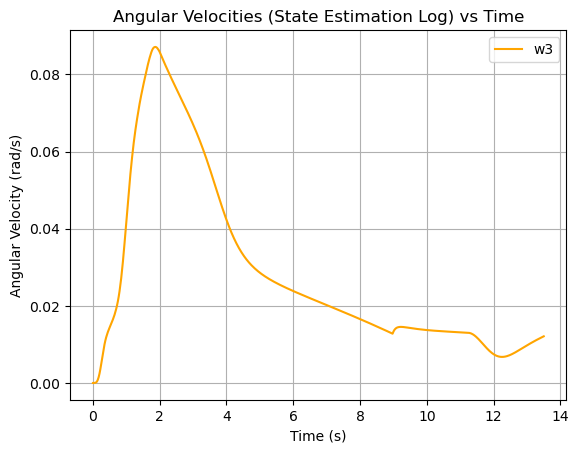

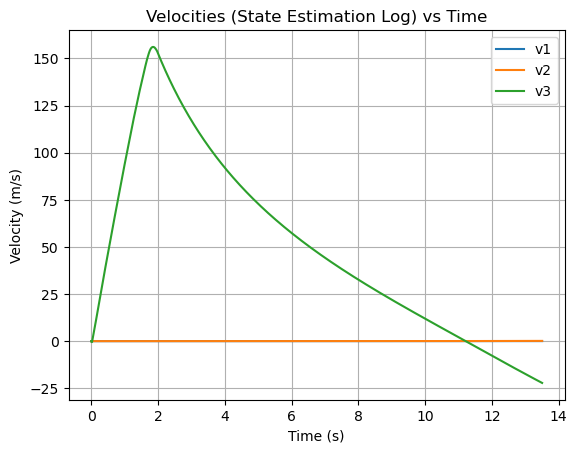

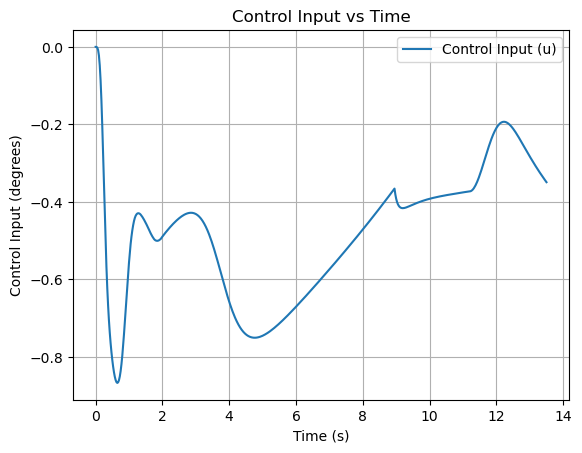

In [19]:
data = pd.read_csv(Path("..") / "data" / "silsim_output2.csv")

t_hat = data['time'].to_numpy()
w1_hat = data['xhat_0'].to_numpy()
w2_hat = data['xhat_1'].to_numpy()
w3_hat = data['xhat_2'].to_numpy()
v1_hat = data['xhat_3'].to_numpy()
v2_hat = data['xhat_4'].to_numpy()
v3_hat = data['xhat_5'].to_numpy()
q0_hat = data['xhat_6'].to_numpy()
q1_hat = data['xhat_7'].to_numpy()
q2_hat = data['xhat_8'].to_numpy()
q3_hat = data['xhat_9'].to_numpy()
u_hat = data['input_0'].to_numpy()

plt.figure()
# plt.plot(t, w1, label='w1')
# plt.plot(t, w2, label='w2')
plt.plot(t_hat, (w3_hat), label='w3', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.title('Angular Velocities (State Estimation Log) vs Time')
# plt.ylim(-0.1, 0.1)
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(t_hat, v1_hat, label='v1')
plt.plot(t_hat, v2_hat, label='v2')
plt.plot(t_hat, v3_hat, label='v3')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocities (State Estimation Log) vs Time')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(t_hat, u_hat, label='Control Input (u)')
plt.xlabel('Time (s)')
plt.ylabel('Control Input (degrees)')
plt.title('Control Input vs Time')
plt.legend()
plt.grid()
plt.show()

# Comparison

Compare State Estimation data vs Rocketpy data

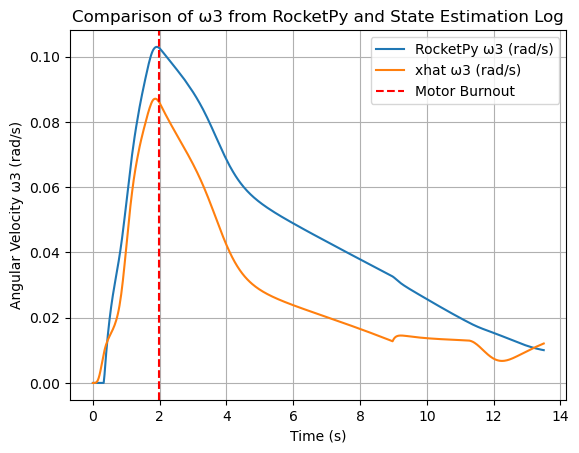

In [20]:
# Compare w3 from rocketpy and SIL
plt.figure()
plt.plot(t_rpy, w3_rpy, label='RocketPy ω3 (rad/s)')
plt.plot(t_hat, w3_hat, label='xhat ω3 (rad/s)')
plt.axvline(x=1.971, color='r', linestyle='--', label='Motor Burnout')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity ω3 (rad/s)')
plt.title('Comparison of ω3 from RocketPy and State Estimation Log')
# plt.ylim(-0.1, 0.1)
plt.legend()
plt.grid()
plt.show()

State estimate error plot

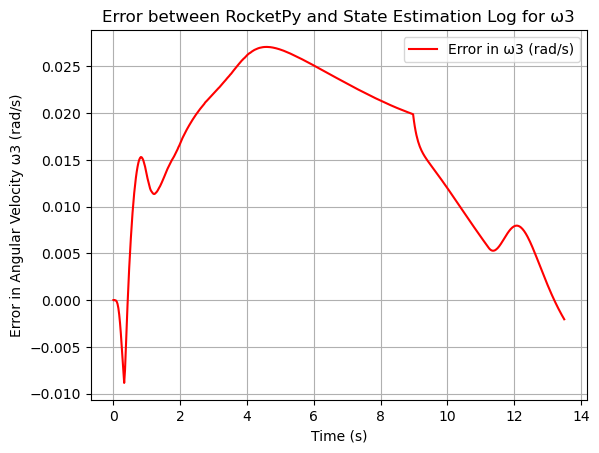

In [21]:
# Plot error between rocketpy and silsim w3
plt.figure()
plt.plot(t_rpy, w3_rpy - w3_hat, label='Error in ω3 (rad/s)', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Error in Angular Velocity ω3 (rad/s)')
plt.title('Error between RocketPy and State Estimation Log for ω3')
plt.legend()
plt.grid()
plt.show()

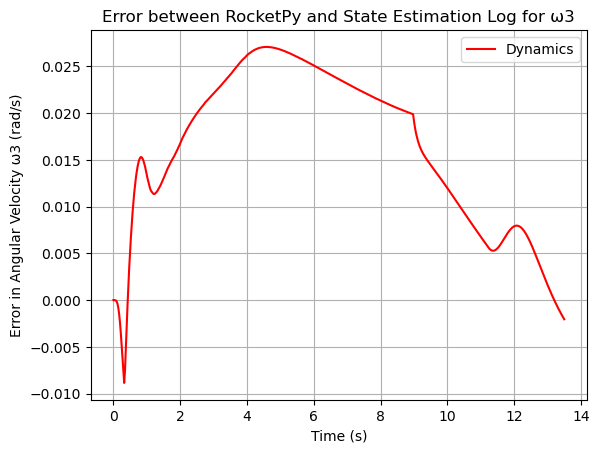

In [22]:
data_rpy = pd.read_csv(Path("..") / "data" / "silsim_output2.csv")

t_rpy2 = data_rpy['time'].to_numpy()
x_rpy = data_rpy['state_0'].to_numpy()
y_rpy = data_rpy['state_1'].to_numpy()
z_rpy = data_rpy['state_2'].to_numpy()
v1_rpy = data_rpy['state_3'].to_numpy()
v2_rpy = data_rpy['state_4'].to_numpy()
v3_rpy = data_rpy['state_5'].to_numpy()
e0_rpy = data_rpy['state_6'].to_numpy()
e1_rpy = data_rpy['state_7'].to_numpy()
e2_rpy = data_rpy['state_8'].to_numpy()
e3_rpy = data_rpy['state_9'].to_numpy()
w1_rpy = data_rpy['state_10'].to_numpy()
w2_rpy = data_rpy['state_11'].to_numpy()
w3_rpy2 = data_rpy['state_12'].to_numpy()

data = pd.read_csv(Path("..") / "data" / "silsim_output2.csv")

t_hat = data['time'].to_numpy()
w1_hat = data['xhat_0'].to_numpy()
w2_hat = data['xhat_1'].to_numpy()
w3_hat2 = data['xhat_2'].to_numpy()
v1_hat = data['xhat_3'].to_numpy()
v2_hat = data['xhat_4'].to_numpy()
v3_hat = data['xhat_5'].to_numpy()
q0_hat = data['xhat_6'].to_numpy()
q1_hat = data['xhat_7'].to_numpy()
q2_hat = data['xhat_8'].to_numpy()
q3_hat = data['xhat_9'].to_numpy()
u_hat = data['input_0'].to_numpy()

# Plot error between rocketpy and silsim w3
plt.figure()
plt.plot(t_rpy2, w3_rpy2 - w3_hat2, label='Dynamics', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Error in Angular Velocity ω3 (rad/s)')
plt.title('Error between RocketPy and State Estimation Log for ω3')
plt.legend()
plt.grid()
plt.show()

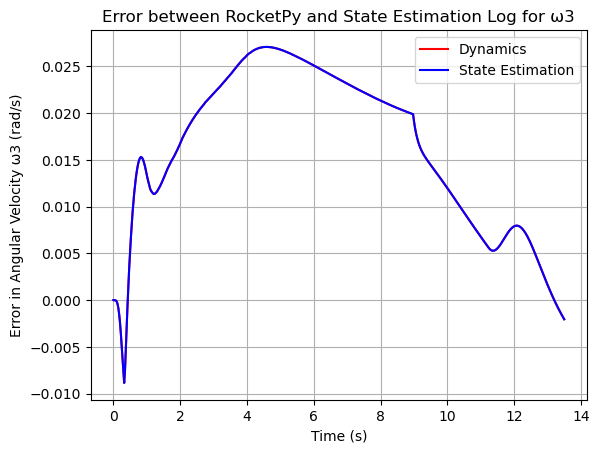

In [23]:
# Plot error between rocketpy and silsim w3
plt.figure()
plt.plot(t_rpy2, w3_rpy2 - w3_hat2, label='Dynamics', color='red')
plt.plot(t_rpy, w3_rpy - w3_hat, label='State Estimation', color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Error in Angular Velocity ω3 (rad/s)')
plt.title('Error between RocketPy and State Estimation Log for ω3')
plt.legend()
plt.grid()
plt.show()